# 📈 Analiză strategică a vânzărilor în magazinul online

**Author:** *Vladut Florian* 


*🔍 Pregătirea datelor pentru analiză vizuală și statistică* într-un context legat de un magazin online

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional pentru stil
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Încărcarea datelor
df = pd.read_csv('online_store_data.csv.csv')

# Previzualizare
df.head()


,product_name,category,price,quantity_in_stock,quantity_sold,brand,rating,num_of_ratings,date_added,color,revenue
0,"iPad mini (2021) (64GB, Blue)",Tablets,499.00,266.0,185.0,Apple,8.75,151.0,2/2/2022,blue,92315.00
1,K55 RGB (Red),Keyboards,49.99,0.0,561.0,Corsair,8.50,455.0,8/14/2022,red,28044.39
2,Fenix 7 (Purple),Watches,699.99,0.0,374.0,Garmin,9.20,305.0,4/20/2022,purple,261796.26
3,"Mate 40 (256GB, Orange)",Smartphones,899.00,182.0,615.0,Huawei,8.50,500.0,10/23/2024,orange,552885.00
4,Rival 600 (Red),Mice,79.99,35.0,698.0,SteelSeries,9.25,556.0,9/29/2020,red,55833.02


## 🔍 Explorare inițială a datelor

Vom analiza structura, tipurile de coloane și valorile lipsă pentru a înțelege ce date avem la dispoziție.


In [16]:
# Informatii generale
df.info()

# Statistici sumare
df.describe()

# Verificare valori lipsă
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3078 entries, 0 to 3077
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_name       3078 non-null   object 
 1   category           3078 non-null   object 
 2   price              3076 non-null   float64
 3   quantity_in_stock  3034 non-null   float64
 4   quantity_sold      3077 non-null   float64
 5   brand              3078 non-null   object 
 6   rating             2938 non-null   float64
 7   num_of_ratings     3069 non-null   float64
 8   date_added         3078 non-null   object 
 9   color              3078 non-null   object 
 10  revenue            3075 non-null   float64
dtypes: float64(6), object(5)
memory usage: 264.6+ KB


product_name           0
category               0
price                  2
quantity_in_stock     44
quantity_sold          1
brand                  0
rating               140
num_of_ratings         9
date_added             0
color                  0
revenue                3
dtype: int64

## 📊 Distribuția vânzărilor (unități vândute)

Analizăm cum sunt distribuite produsele în funcție de numărul de unități vândute.


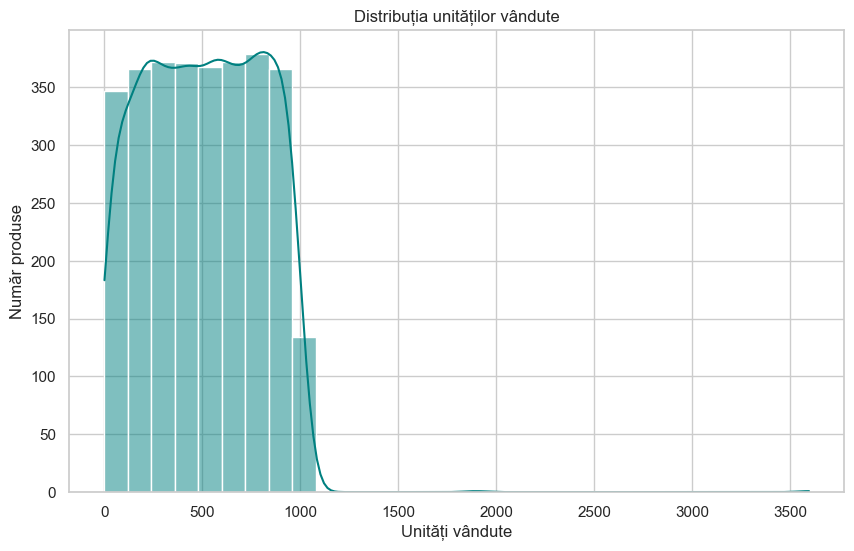

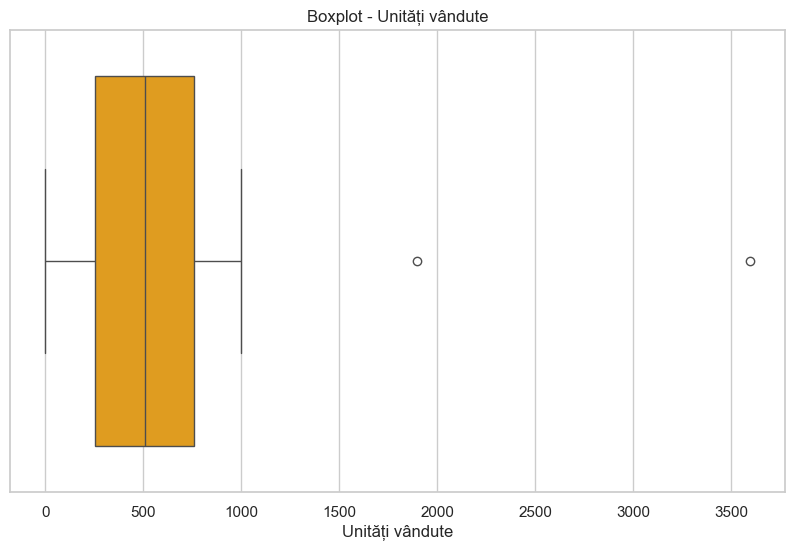

In [17]:
# Histogramă
sns.histplot(df['quantity_sold'], bins=30, kde=True, color='teal')
plt.title('Distribuția unităților vândute')
plt.xlabel('Unități vândute')
plt.ylabel('Număr produse')
plt.show()

# Boxplot pentru evidențiere outlieri
sns.boxplot(x=df['quantity_sold'], color='orange')
plt.title('Boxplot - Unități vândute')
plt.xlabel('Unități vândute')
plt.show()


## 🧺 Performanța pe categorii de produse

Comparăm volumul vânzărilor între diferite categorii de produse.


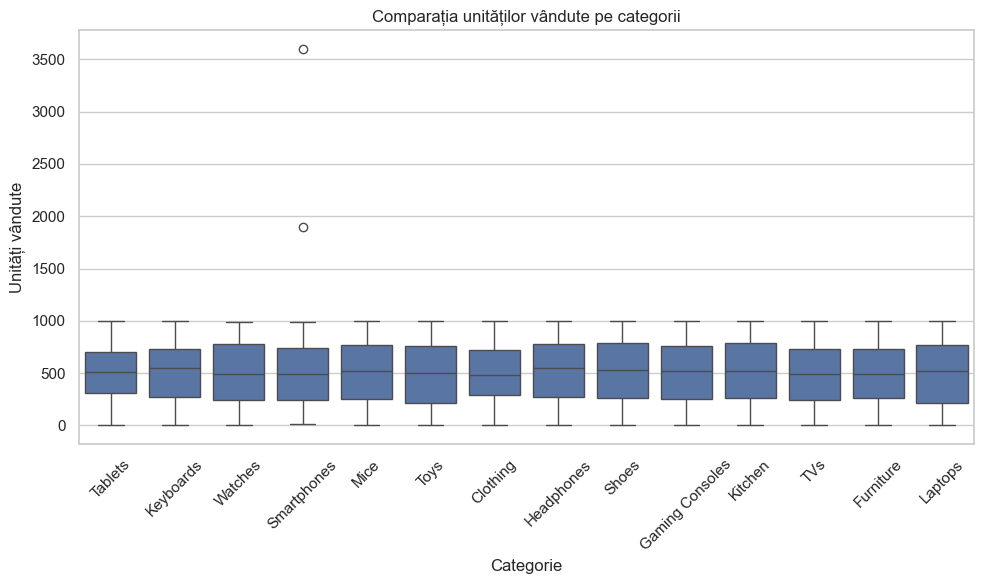

In [18]:
# Boxplot vânzari pe categorie
sns.boxplot(x='category', y='quantity_sold', data=df)
plt.title('Comparația unităților vândute pe categorii')
plt.xticks(rotation=45)
plt.xlabel('Categorie')
plt.ylabel('Unități vândute')
plt.tight_layout()
plt.show()


## 🔗 Analiza corelațiilor între variabile

Vom identifica ce factori numerici influențează vânzările: preț, rating, stoc, venit etc.


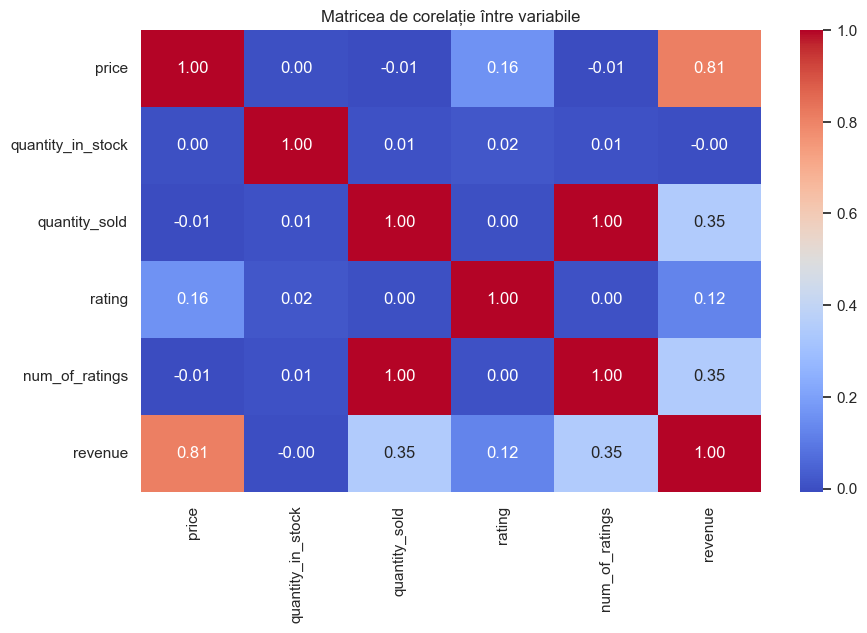

In [19]:
# Alegem coloanele numerice existente
num_cols = ['price', 'quantity_in_stock', 'quantity_sold', 'rating', 'num_of_ratings', 'revenue']
corr_matrix = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matricea de corelație între variabile')
plt.show()


## 📌 Analiza vizuală a factorilor de succes

Vizualizăm legăturile dintre factori cheie și vânzări folosind scatter plot-uri.


In [ ]:

sns.scatterplot(
    x='price',
    y='quantity_sold',
    hue='category',
    size='revenue',
    data=df,
    alpha=0.7
)
plt.title('Preț vs. Unități vândute')
plt.xlabel('Preț')
plt.ylabel('Unități vândute')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `units_sold` for `y`. An entry with this name does not appear in `data`.

In [ ]:
sns.scatterplot(
    x='rating',
    y='quantity_sold',
    hue='category',
    size='quantity_in_stock',
    data=df,
    alpha=0.7
)
plt.title('Rating vs. Unități vândute')
plt.xlabel('Rating')
plt.ylabel('Unități vândute')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## ✅ Concluzii strategice

- 🔝 Cele mai vândute produse se concentrează în anumite categorii (ex: ...), dar există și „hituri” surprinzătoare în alte segmente.
- 🧺 Categoria **X** domină clar în vânzări, în timp ce **Y** performează sub așteptări.
- 💰 Corelația puternică între **venit și unități vândute** arată că succesul nu depinde doar de preț – ci și de volum.
- 📌 Evaluările clienților influențează pozitiv vânzările, dar efectul lor este mai vizibil la produse cu preț mediu.
- 🧮 Analiza oferă echipei de achiziții și marketing direcții clare: ce categorii să susțină și ce tip de produse merită promovate.
